# Real-farm inter-farm wake loss: existing neighbours, future build-out, PyWake benchmark

This notebook implements the changes agreed with the supervisors:

1. Use real wind farms and **actual turbine locations** (GOWF v1.3 dataset) wherever coordinates exist, instead of synthetic square neighbours.
2. Include the **existing neighbouring farms** around the target farm.
3. Add a **future build-out** scenario (planned farms on top of the existing ones).
4. **Benchmark the ML surrogate against PyWake** for exactly the same layouts and wind states.
5. Use the site's **ERA5 wind rose** and aggregate over wind speed and direction to get a representative (AEP-weighted) wake loss.

It reuses the existing `wake_uncertainty` functions (`place_turbines`, `compute_geometric_features`, `project_polygon`, `load_model`) and the
PyWake set-up from `training_data_generation.ipynb` (Nygaard_2022 / TurbOPark, `XRSite`, `GenericWindTurbine`), so the PyWake numbers here are
produced the same way as the training labels.

In [1]:
import os
import sys
import glob
import time
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import weibull_min

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("..", "src")))

from wake_uncertainty.config import FEATURES, KW_JENSEN
from wake_uncertainty.model import load_model
from wake_uncertainty.utils import place_turbines, compute_geometric_features

from py_wake.site import XRSite
from py_wake.wind_turbines import WindTurbines
from py_wake.wind_turbines.generic_wind_turbines import GenericWindTurbine
from py_wake.literature import Nygaard_2022
import logging
logging.getLogger().setLevel(logging.ERROR)   # the package logs every feature dict at INFO, which slows the loops below

DATA_DIR = "../data"
GOWF_FILE = os.path.join(DATA_DIR, "gowf", "GOWF_V1.3.shp")
FARM_FILE = os.path.join(DATA_DIR, "gdf.gpkg")
ERA5_DIR = os.path.join(DATA_DIR, "era5")
FIG_DIR = "../figures"
RANDOM_SEED = 42

## Settings

Two target sites are configured. Pick one with `TARGET_FARM` (or the `WAKE_TARGET` environment variable).

* **Anholt** (Denmark, default): isolated today, so the planned Kattegat projects show the future build-out effect clearly.
  Future farms: Hesselø, Kattegatt Syd and the EMODnet "Trem Mkllebugt" area. Kattegat I/II and Hesselk are left out by default
  (Kattegat I is a 914 km2 search area and none of the three has a capacity in EMODnet). Add them to `future` to test them.
* **Norther** (Belgium): already inside a dense cluster (Belgian zone + Borssele), with the Princess Elisabeth Zone (PEZ) as future build-out.

Turbine models are not in either dataset, so they are taken from public project information. **Check these and the future capacities
(several Kattegat projects have been paused or re-tendered) before the paper.** Hub heights are approximate.

In [2]:
TARGET_FARM = os.environ.get("WAKE_TARGET", "Anholt")

TURBINES = {
    "V164-8.4":    dict(diameter=164, hub_height=105, rated_power=8400),
    "Senvion-6.2": dict(diameter=126, hub_height=94,  rated_power=6150),
    "SWT-7.0-154": dict(diameter=154, hub_height=106, rated_power=7350),
    "SWT-3.6-120": dict(diameter=120, hub_height=82,  rated_power=3600),
    "V112-3.0":    dict(diameter=112, hub_height=72,  rated_power=3000),
    "V90-3.0":     dict(diameter=90,  hub_height=72,  rated_power=3000),
    "V112-3.3":    dict(diameter=112, hub_height=79,  rated_power=3300),
    "V164-9.5":    dict(diameter=164, hub_height=109, rated_power=9500),
    "SG-8.0-167":  dict(diameter=167, hub_height=109, rated_power=8400),
    "15MW-236":    dict(diameter=236, hub_height=140, rated_power=15000),
}

SITES = {
    "Anholt": dict(
        epsg=32632, era5="anholt",
        existing={"Anholt": "SWT-3.6-120"},
        # future farm -> capacity in MW (None = use EMODnet power_mw)
        future={"Hesselø": 1000, "Kattegatt Syd": None, "Trem Mkllebugt": None},
        share_future_by_area=False,
    ),
    "Norther": dict(
        epsg=32631, era5="norther",
        existing={
            "Norther":            "V164-8.4",
            "C-Power":            "Senvion-6.2",
            "Rentel":             "SWT-7.0-154",
            "Northwind":          "V112-3.0",
            "Belwind phase 1":    "V90-3.0",
            "Nobelwind":          "V112-3.3",
            "Northwester 2":      "V164-9.5",
            "Seamade (SeaStar)":  "SG-8.0-167",
            "Mermaid":            "SG-8.0-167",
            "Borssele I":         "SG-8.0-167",
            "Borssele Kavel II":  "SG-8.0-167",
            "Borssele Kavel III": "V164-9.5",
            "Borssele Kavel IV":  "V164-9.5",
            "Borssele Kavel V":   "V164-9.5",
        },
        future={"Princess Elisabeth Zone Lot 1": None, "Princess Elisabeth Zone Lot 2.1": None,
                "Princess Elisabeth Zone Lot 2.2": None, "Princess Elisabeth Zone Lot 3": None},
        # EMODnet gives 700/700/700/1400 MW for the PEZ lots but Lot 2.1 is only 12 km2, so the zone total is shared out by area
        share_future_by_area=True,
    ),
}

site = SITES[TARGET_FARM]
EPSG = site["epsg"]
EXISTING_FARMS = site["existing"]
FUTURE_FARMS = list(site["future"])

# Future turbine. Set FUTURE_TURBINE = "SG-8.0-167" to keep the ML surrogate inside its training range (max rotor 167 m, 8.4 MW).
FUTURE_TURBINE = "15MW-236"
FUTURE_SPACING_D = 6          # minimum spacing used to place future turbines
N_MC_FUTURE = 10              # random future layouts for layout uncertainty
FIG_PREFIX = f"real_farms_{TARGET_FARM.lower()}"
print("Target:", TARGET_FARM, "| existing neighbours:", len(EXISTING_FARMS) - 1, "| future farms:", FUTURE_FARMS)

# Use GOWF positions when GOWF holds at least this fraction of the farm's turbines; otherwise place turbines in the real polygon.
GOWF_MIN_FRACTION = 0.9
SYNTHETIC_SPACING_D = 5

# Wind-rose discretisation (training data used wd in 30 deg steps and ws 4-15 m/s)
WD_BINS = np.arange(0, 360, 30)
WS_BINS = np.arange(4, 26, 1.0)
TI = 0.06
ML_WS_MAX = 15.0              # top of the training range; above this the surrogate extrapolates

Target: Anholt | existing neighbours: 0 | future farms: ['Hesselø', 'Kattegatt Syd', 'Trem Mkllebugt']


## 1. Verify the GOWF turbine-position data

In [3]:
gowf = gpd.read_file(GOWF_FILE)
print("CRS:", gowf.crs, "| points:", len(gowf), "| geometry:", gowf.geom_type.unique().tolist())
print("Columns:", gowf.columns.drop("geometry").tolist())
print("Empty / invalid geometries:", int(gowf.is_empty.sum()), int((~gowf.is_valid).sum()))
print("Commissioning years:", gowf.occ_year.value_counts().sort_index().to_dict())
print(gowf.groupby("continent").size().to_dict())

xy_ll = np.c_[gowf.geometry.x, gowf.geometry.y]
lon_ok = (np.abs(xy_ll[:, 0]) <= 180).all() and (np.abs(xy_ll[:, 1]) <= 90).all()
print("Coordinates in lon/lat range:", lon_ok)

gowf_utm = gowf.to_crs(epsg=EPSG)
d, _ = cKDTree(np.c_[gowf_utm.geometry.x, gowf_utm.geometry.y]).query(np.c_[gowf_utm.geometry.x, gowf_utm.geometry.y], k=2)
print("Exact duplicate points:", int((d[:, 1] == 0).sum()), "| points closer than 100 m to another:", int((d[:, 1] < 100).sum()))
gowf_utm = gowf_utm.loc[~gowf_utm.geometry.duplicated()].reset_index(drop=True)

CRS: EPSG:4326 | points: 6924 | geometry: ['Point']
Columns: ['centr_lat', 'centr_lon', 'continent', 'country', 'sea_area', 'occ_year', 'occ_month']
Empty / invalid geometries: 0 0
Commissioning years: {2015: 3368, 2016: 1175, 2017: 1094, 2018: 870, 2019: 417}
{'Asia': 1940, 'Europe': 4979, 'North America': 5}
Coordinates in lon/lat range: True
Exact duplicate points: 2 | points closer than 100 m to another: 2


GOWF is a satellite-derived inventory with commissioning dates up to 2019. It has no farm names, turbine models or rotor sizes, so each point is
matched to its EMODnet farm polygon below, and farms built after 2019 are missing.

In [4]:
farms_all = gpd.read_file(FARM_FILE).to_crs(epsg=EPSG)
names_needed = list(EXISTING_FARMS) + FUTURE_FARMS
missing = [n for n in names_needed if n not in set(farms_all.name)]
assert not missing, f"Farm names not found in gdf.gpkg: {missing}"
farms = farms_all.set_index("name").loc[names_needed].reset_index()
farms["area_rank"] = farms.geometry.area

# assign each GOWF point to the smallest existing-farm polygon (300 m buffer) that contains it
existing_polys = farms[farms.name.isin(EXISTING_FARMS)].copy()
existing_polys["geometry"] = existing_polys.geometry.buffer(300)
joined = gpd.sjoin(gowf_utm, existing_polys[["name", "area_rank", "geometry"]], predicate="within")
joined = joined.sort_values("area_rank").loc[lambda j: ~j.index.duplicated(keep="first")]

check = farms[farms.name.isin(EXISTING_FARMS)][["name", "status", "n_turbines", "power_mw", "year"]].copy()
check["gowf_points"] = check.name.map(joined.groupby("name").size()).fillna(0).astype(int)
check["gowf_fraction"] = (check.gowf_points / check.n_turbines).round(2)
check["layout_source"] = np.where(check.gowf_fraction >= GOWF_MIN_FRACTION, "GOWF", "synthetic in real polygon")
check

,name,status,n_turbines,power_mw,year,gowf_points,gowf_fraction,layout_source
0,Anholt,Production,111.0,399.6,2012.0,111,1.0,GOWF


Farms with slightly more GOWF points than EMODnet turbines most likely include their offshore substation, which looks like a turbine in SAR imagery.
For those farms the surplus points closest to their nearest neighbour are dropped (substations sit close to turbines, turbines do not).

In [5]:
def farm_turbines_from_gowf(name, n_expected):
    pts = joined[joined.name == name]
    xy = np.c_[pts.geometry.x, pts.geometry.y]
    surplus = len(xy) - int(n_expected)
    if surplus > 0:
        nn = cKDTree(xy).query(xy, k=2)[0][:, 1]
        xy = np.delete(xy, np.argsort(nn)[:surplus], axis=0)
    return xy

## 2. Build turbine layouts: target, existing neighbours, future build-out

Farms with GOWF coverage use their real turbine positions. Farms built after 2019 and the future farms are filled with
`place_turbines` inside their **real EMODnet polygon** (no square farms, no polygon expansion; spacing is reduced in 0.5D steps if needed).

In [6]:
def place_in_real_polygon(polygon, n_turbines, diameter, spacing_D, seed):
    """place_turbines without polygon expansion: relax spacing instead so turbines stay inside the real lease area."""
    sp = spacing_D
    while sp >= 2:
        x, y, _ = place_turbines(polygon, n_turbines, sp * diameter, seed=seed, max_expand_attempts=0)
        if len(x) == n_turbines:
            return np.c_[x, y], sp
        sp -= 0.5
    raise ValueError(f"Could not place {n_turbines} turbines in polygon")


def turbine_count(row, model):
    if pd.notna(row.n_turbines) and row.n_turbines > 0:
        return int(row.n_turbines)
    return int(round(row.power_mw * 1000 / TURBINES[model]["rated_power"]))


layout_rows = []
for _, row in farms[farms.name.isin(EXISTING_FARMS)].iterrows():
    model = EXISTING_FARMS[row["name"]]
    n = turbine_count(row, model)
    src = check.set_index("name").loc[row["name"], "layout_source"]
    if src == "GOWF":
        xy = farm_turbines_from_gowf(row["name"], n)
        used_sp = np.nan
    else:
        xy, used_sp = place_in_real_polygon(row.geometry, n, TURBINES[model]["diameter"], SYNTHETIC_SPACING_D, RANDOM_SEED)
    for x, y in xy:
        layout_rows.append(dict(farm=row["name"], model=model, x=x, y=y, source=src, group="existing"))
    print(f"{row['name']:<22} {model:<12} n={len(xy):>3}  source={src}" + ("" if np.isnan(used_sp) else f" (spacing {used_sp}D)"))

layout_existing = pd.DataFrame(layout_rows)
layout_existing.loc[layout_existing.farm == TARGET_FARM, "group"] = "target"


future_polys = farms[farms.name.isin(FUTURE_FARMS)].copy()
future_polys["capacity_mw"] = [site["future"][n] if site["future"][n] is not None else p
                               for n, p in zip(future_polys.name, future_polys.power_mw)]
assert future_polys.capacity_mw.notna().all(), "Give a capacity for every future farm without an EMODnet power_mw"
future_total_mw = future_polys.capacity_mw.sum()
if site["share_future_by_area"]:
    future_polys["capacity_mw"] = future_total_mw * future_polys.geometry.area / future_polys.geometry.area.sum()
future_polys["n_turbines_used"] = np.round(future_polys.capacity_mw * 1000 / TURBINES[FUTURE_TURBINE]["rated_power"]).astype(int)
print(f"Future build-out: {future_total_mw:.0f} MW over {future_polys.geometry.area.sum() / 1e6:.0f} km2")
print(future_polys.assign(area_km2=future_polys.geometry.area / 1e6)[["name", "power_mw", "capacity_mw", "area_km2", "n_turbines_used"]].round(1))


def future_layout(seed):
    rows = []
    for _, row in future_polys.iterrows():
        n = int(row.n_turbines_used)
        xy, sp = place_in_real_polygon(row.geometry, n, TURBINES[FUTURE_TURBINE]["diameter"], FUTURE_SPACING_D, seed)
        rows += [dict(farm=row["name"], model=FUTURE_TURBINE, x=x, y=y, source=f"planned, {sp}D", group="future") for x, y in xy]
    return pd.DataFrame(rows)


layout_future = future_layout(RANDOM_SEED)
print(layout_future.groupby(["farm", "source"]).size())

Anholt                 SWT-3.6-120  n=111  source=GOWF
Future build-out: 2920 MW over 321 km2
             name  power_mw  capacity_mw  area_km2  n_turbines_used
1         Hesselø       NaN       1000.0     165.5               67
2   Kattegatt Syd    1200.0       1200.0     102.8               80
3  Trem Mkllebugt     720.0        720.0      52.2               48


farm            source       
Hesselø         planned, 5.5D    67
Kattegatt Syd   planned, 4.0D    80
Trem Mkllebugt  planned, 3.5D    48
dtype: int64


In [7]:
# nearest-neighbour spacing per farm, in rotor diameters, as a sanity check of the positions
def spacing_table(layout):
    out = []
    for (farm, model), g in layout.groupby(["farm", "model"]):
        nn = cKDTree(g[["x", "y"]].values).query(g[["x", "y"]].values, k=2)[0][:, 1]
        out.append(dict(farm=farm, model=model, n=len(g), source=g.source.iloc[0],
                        min_spacing_D=nn.min() / TURBINES[model]["diameter"],
                        median_spacing_D=np.median(nn) / TURBINES[model]["diameter"]))
    return pd.DataFrame(out).round(2)

spacing_table(pd.concat([layout_existing, layout_future]))

,farm,model,n,source,min_spacing_D,median_spacing_D
0,Anholt,SWT-3.6-120,111,GOWF,4.88,5.79
1,Hesselø,15MW-236,67,"planned, 5.5D",5.55,5.82
2,Kattegatt Syd,15MW-236,80,"planned, 4.0D",4.00,4.23
3,Trem Mkllebugt,15MW-236,48,"planned, 3.5D",3.53,3.76


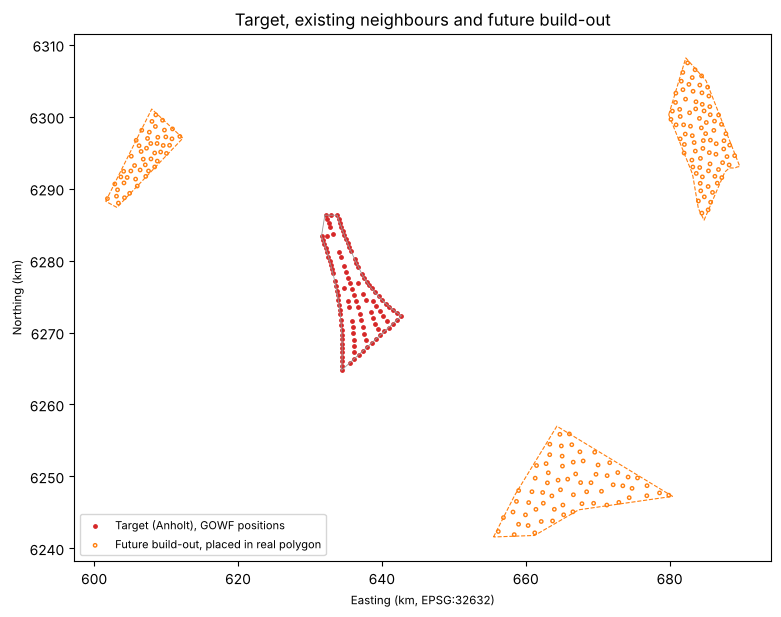

In [8]:
fig, ax = plt.subplots(figsize=(9, 9))
km = lambda g: g.set_geometry(g.geometry.scale(1e-3, 1e-3, origin=(0, 0)))
km(farms[farms.name.isin(EXISTING_FARMS)]).boundary.plot(ax=ax, color="0.6", lw=0.6)
km(farms[farms.name.isin(FUTURE_FARMS)]).boundary.plot(ax=ax, color="tab:orange", lw=0.8, ls="--")
styles = {"target": ("tab:red", f"Target ({TARGET_FARM})"), "existing": ("tab:blue", "Existing"), "future": ("tab:orange", "Future build-out")}
all_layout = pd.concat([layout_existing, layout_future])
for grp, (col, lab) in styles.items():
    g = all_layout[all_layout.group == grp]
    real = g.source == "GOWF"
    if real.any():
        ax.scatter(g.x[real] / 1e3, g.y[real] / 1e3, s=6, c=col, label=f"{lab}, GOWF positions")
    if (~real).any():
        ax.scatter(g.x[~real] / 1e3, g.y[~real] / 1e3, s=6, facecolors="none", edgecolors=col, label=f"{lab}, placed in real polygon")
ax.set_aspect("equal"); ax.set_xlabel(f"Easting (km, EPSG:{EPSG})"); ax.set_ylabel("Northing (km)")
ax.legend(fontsize=8, loc="lower left"); ax.set_title("Target, existing neighbours and future build-out")
plt.savefig(os.path.join(FIG_DIR, f"{FIG_PREFIX}_layout.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Site wind rose from ERA5

Same sector/Weibull fit as `training_data_generation.ipynb` (`wake_uncertainty.utils.load_era5_wind_rose` passes a glob string to xarray, which
fails, so the notebook version is used here).

In [9]:
def load_era5_wind_rose(data_dir):
    files = sorted(glob.glob(os.path.join(data_dir, "era5_*.nc")))
    ds = xr.open_mfdataset(files)
    u = ds["u100"].values.ravel(); v = ds["v100"].values.ravel()
    ok = np.isfinite(u) & np.isfinite(v); u, v = u[ok], v[ok]
    ws = np.sqrt(u ** 2 + v ** 2)
    wd = (270 - np.degrees(np.arctan2(v, u))) % 360
    rows = []
    for sector in WD_BINS:
        lo, hi = (sector - 15) % 360, (sector + 15) % 360
        mask = (wd >= lo) | (wd < hi) if lo > hi else (wd >= lo) & (wd < hi)
        k, _, a = weibull_min.fit(ws[mask][ws[mask] > 0.5], floc=0)
        rows.append(dict(direction_deg=sector, frequency=mask.sum() / len(ws), weibull_A=a, weibull_k=k))
    wr = pd.DataFrame(rows)
    wr["frequency"] /= wr["frequency"].sum()
    return wr, ws


wind_rose, ws_samples = load_era5_wind_rose(os.path.join(ERA5_DIR, site["era5"]))
print(f"ERA5 samples: {len(ws_samples)}, mean 100 m wind speed {ws_samples.mean():.2f} m/s, "
      f"share above {ML_WS_MAX:.0f} m/s: {(ws_samples > ML_WS_MAX).mean():.1%}")

# probability of each (wd, ws) bin: sector frequency x Weibull probability of the 1 m/s bin
edges = np.r_[WS_BINS - 0.5, WS_BINS[-1] + 0.5]
P = np.zeros((len(WD_BINS), len(WS_BINS)))
for i, r in wind_rose.iterrows():
    cdf = weibull_min.cdf(edges, r.weibull_k, scale=r.weibull_A)
    P[i] = r.frequency * np.diff(cdf)
print(f"Probability covered by ws {WS_BINS[0]:.0f}-{WS_BINS[-1]:.0f} m/s: {P.sum():.3f}")
wind_rose.round(3)

ERA5 samples: 420864, mean 100 m wind speed 8.82 m/s, share above 15 m/s: 7.4%
Probability covered by ws 4-25 m/s: 0.911


,direction_deg,frequency,weibull_A,weibull_k
0,0,0.048,8.185,2.109
1,30,0.041,7.658,2.221
2,60,0.046,7.962,2.259
3,90,0.065,10.149,2.066
4,120,0.077,9.667,2.350
5,150,0.088,9.944,2.383
6,180,0.082,9.965,2.286
7,210,0.117,10.848,2.440
8,240,0.144,10.582,2.541
9,270,0.159,11.156,2.527


## 4. PyWake reference (same set-up as the training labels)

In [10]:
def pywake_target_power(layout, target_name=TARGET_FARM):
    """Return target-turbine power (kW) as array [turbine, wd, ws] from Nygaard_2022 over the full wind-rose grid."""
    models = list(dict.fromkeys(layout.model))
    wts = WindTurbines.from_WindTurbine_lst(
        [GenericWindTurbine(m, TURBINES[m]["diameter"], TURBINES[m]["hub_height"], TURBINES[m]["rated_power"]) for m in models])
    types = layout.model.map({m: i for i, m in enumerate(models)}).values
    ds = xr.Dataset(data_vars={"Sector_frequency": ("wd", wind_rose.frequency.values),
                               "Weibull_A": ("wd", wind_rose.weibull_A.values),
                               "Weibull_k": ("wd", wind_rose.weibull_k.values),
                               "TI": TI},
                    coords={"wd": wind_rose.direction_deg.values})
    wfm = Nygaard_2022(XRSite(ds), wts)
    sim = wfm(layout.x.values, layout.y.values, type=types, wd=WD_BINS, ws=WS_BINS)
    is_target = (layout.farm == target_name).values
    return sim.Power.values[is_target] / 1000.0


layout_target = layout_existing[layout_existing.group == "target"].reset_index(drop=True)
scenarios = {
    "alone": layout_target,
    "existing": layout_existing.reset_index(drop=True),
    "existing+future": pd.concat([layout_existing, layout_future], ignore_index=True),
}
pw = {}
for name, lay in scenarios.items():
    t0 = time.perf_counter()
    pw[name] = pywake_target_power(lay)
    print(f"PyWake {name:<16} {len(lay):>4} turbines  {time.perf_counter() - t0:5.1f} s")

PyWake alone             111 turbines    1.1 s


PyWake existing          111 turbines    1.0 s


PyWake existing+future   306 turbines    6.9 s


## 5. ML surrogate on the same layouts

The surrogate was trained with **one** neighbour farm described by `nb_*` features. With several real neighbours, each target turbine gets the
`nb_*` descriptors of the neighbour farm that dominates its wake exposure for that wind direction:

* the neighbour farm contributing most physics-informed blockers (`compute_geometric_features` run per farm), otherwise
* the nearest farm lying upwind (within ±45° of the wind direction), otherwise
* a "no neighbour" encoding: a farm 50 km **downwind**, which is inside the training distribution and cannot shadow the target.

The `pi_*` topology features always use **all** turbines (target, existing and future) with their own rotor diameters.
The "alone" baseline uses the same downwind encoding, so ML wake loss compares like with like (see the review: the earlier baseline was out of
distribution).

In [11]:
model = load_model()
model = model["model"] if isinstance(model, dict) else model
tgt_spec = TURBINES[EXISTING_FARMS[TARGET_FARM]]
tc = np.array([layout_target.x.mean(), layout_target.y.mean()])


def farm_descriptors(layout):
    desc = {}
    for farm, g in layout[layout.group != "target"].groupby("farm"):
        spec = TURBINES[g.model.iloc[0]]
        c = np.array([g.x.mean(), g.y.mean()])
        dx, dy = c - tc
        nn = cKDTree(g[["x", "y"]].values).query(g[["x", "y"]].values, k=2)[0][:, 1]
        desc[farm] = dict(nb_distance_km=np.hypot(dx, dy) / 1000,
                          nb_direction_deg=np.degrees(np.arctan2(dx, dy)) % 360,   # bearing target -> farm, same convention as make_neighbour_polygon
                          nb_n_turbines=len(g),
                          nb_spacing_D=np.median(nn) / spec["diameter"],
                          nb_rotor_dia_m=spec["diameter"], nb_hub_height_m=spec["hub_height"], nb_rated_power_kw=spec["rated_power"])
    return desc


def no_neighbour(wd):
    s = TURBINES["SG-8.0-167"]
    return dict(nb_distance_km=50.0, nb_direction_deg=(wd + 180) % 360, nb_n_turbines=100, nb_spacing_D=7.0,
                nb_rotor_dia_m=s["diameter"], nb_hub_height_m=s["hub_height"], nb_rated_power_kw=s["rated_power"])


def ml_features(layout):
    """Feature rows for every (target turbine, wd); ws is added later."""
    desc = farm_descriptors(layout)
    xa, ya = layout.x.values, layout.y.values
    Da = layout.model.map(lambda m: TURBINES[m]["diameter"]).values.astype(float)
    tidx = np.where(layout.group.values == "target")[0]
    rows = []
    for wd in WD_BINS:
        upwind = {f: d for f, d in desc.items() if abs((d["nb_direction_deg"] - wd + 180) % 360 - 180) <= 45}
        for k, i in enumerate(tidx):
            others = np.ones(len(xa), bool); others[i] = False
            pi = compute_geometric_features(xa[i], ya[i], Da[i], xa[others], ya[others], Da[others], wd, kw=KW_JENSEN)
            pi = {key: v for key, v in pi.items() if key.startswith("pi_")}
            blockers = {}
            for farm in desc:
                m = (layout.farm.values == farm)
                f = compute_geometric_features(xa[i], ya[i], Da[i], xa[m], ya[m], Da[m], wd, kw=KW_JENSEN)
                if f["pi_n_blocking"] > 0:
                    blockers[farm] = f["pi_n_blocking"]
            if blockers:
                nb = desc[max(blockers, key=blockers.get)]
            elif upwind:
                nb = min(upwind.values(), key=lambda d: d["nb_distance_km"])
            else:
                nb = no_neighbour(wd)
            rows.append(dict(turbine=k, wd=float(wd), ti=TI, target_rotor_dia_m=tgt_spec["diameter"],
                             target_hub_height_m=tgt_spec["hub_height"], target_rated_power_kw=tgt_spec["rated_power"],
                             **nb, **pi))
    return pd.DataFrame(rows)


def ml_target_power(layout):
    feats = ml_features(layout)
    n_t = int((layout.group == "target").sum())
    out = np.zeros((n_t, len(WD_BINS), len(WS_BINS)))
    for j, ws in enumerate(WS_BINS):
        X = feats.assign(ws_free=ws)[FEATURES]
        pr = np.clip(model.predict(X), 0, 1)
        out[feats.turbine.values, np.searchsorted(WD_BINS, feats.wd.values), j] = pr * tgt_spec["rated_power"]
    return out


ml = {}
for name, lay in scenarios.items():
    t0 = time.perf_counter()
    ml[name] = ml_target_power(lay)
    print(f"ML     {name:<16} {time.perf_counter() - t0:5.1f} s")

ML     alone              4.6 s


ML     existing           4.7 s


ML     existing+future   21.2 s


### Extrapolation check
Which inputs fall outside the training data (`data/train/training_data_final.csv`)?

In [12]:
train = pd.read_csv(os.path.join(DATA_DIR, "train", "training_data_final.csv"), usecols=FEATURES)
lo, hi = train.min(), train.max()
for name, lay in scenarios.items():
    f = ml_features(lay).assign(ws_free=WS_BINS.max())[FEATURES]
    out = [c for c in FEATURES if (f[c] < lo[c] - 1e-9).any() or (f[c] > hi[c] + 1e-9).any()]
    print(f"{name:<16} features outside training range: {out}")
print(f"ws_free above {ML_WS_MAX} m/s is outside the training range for every scenario.")

alone            features outside training range: ['ws_free', 'nb_distance_km', 'nb_hub_height_m']


existing         features outside training range: ['ws_free', 'nb_distance_km', 'nb_hub_height_m']


existing+future  features outside training range: ['ws_free', 'nb_distance_km', 'nb_spacing_D', 'nb_rotor_dia_m', 'nb_hub_height_m', 'nb_rated_power_kw', 'pi_blocking_distance', 'pi_streamwise_dist_1st', 'pi_lateral_dist_1st', 'pi_rotor_dia_1st']
ws_free above 15.0 m/s is outside the training range for every scenario.


## 6. Benchmark: ML vs PyWake on identical scenarios

In [13]:
def farm_power(arr):          # [turbine, wd, ws] -> [wd, ws]
    return arr.sum(axis=0)

in_range = WS_BINS <= ML_WS_MAX
rows = []
for name in scenarios:
    p, m = pw[name], ml[name]
    for label, sel in [("4-15 m/s (training range)", in_range), ("4-25 m/s (all)", np.ones_like(in_range))]:
        a, b = p[:, :, sel] / tgt_spec["rated_power"], m[:, :, sel] / tgt_spec["rated_power"]
        fa, fb = farm_power(p[:, :, sel]), farm_power(m[:, :, sel])
        ss_res = ((a - b) ** 2).sum(); ss_tot = ((a - a.mean()) ** 2).sum()
        rows.append(dict(scenario=name, ws_range=label, turbine_R2=1 - ss_res / ss_tot,
                         turbine_MAE=np.abs(a - b).mean(),
                         farm_power_MAPE_pct=(np.abs(fb - fa) / np.maximum(fa, 1)).mean() * 100,
                         farm_power_bias_pct=((fb - fa).sum() / fa.sum()) * 100))
benchmark = pd.DataFrame(rows).round(4)
benchmark

,scenario,ws_range,turbine_R2,turbine_MAE,farm_power_MAPE_pct,farm_power_bias_pct
0,alone,4-15 m/s (training range),0.9939,0.0092,1.4307,0.0347
1,alone,4-25 m/s (all),0.9961,0.0057,0.8519,-0.0794
2,existing,4-15 m/s (training range),0.9939,0.0092,1.4307,0.0347
3,existing,4-25 m/s (all),0.9961,0.0057,0.8519,-0.0794
4,existing+future,4-15 m/s (training range),0.9918,0.0132,2.1173,0.2312
5,existing+future,4-25 m/s (all),0.9947,0.0082,1.2597,-0.0450


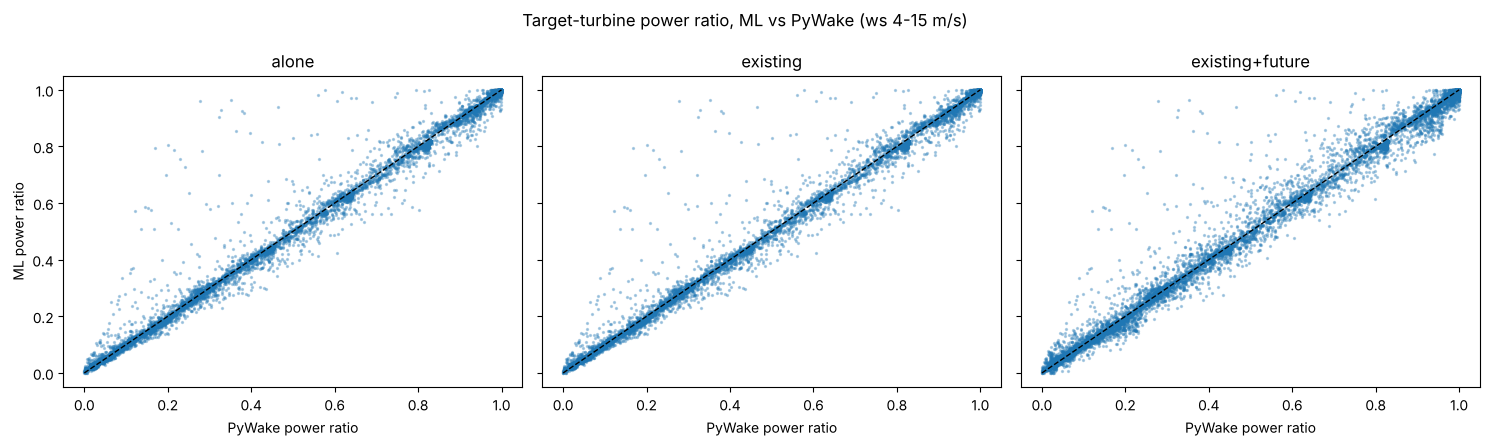

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, name in zip(axes, scenarios):
    p = pw[name][:, :, in_range].ravel() / tgt_spec["rated_power"]
    m = ml[name][:, :, in_range].ravel() / tgt_spec["rated_power"]
    ax.scatter(p, m, s=2, alpha=0.3)
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"{name}"); ax.set_xlabel("PyWake power ratio")
axes[0].set_ylabel("ML power ratio")
plt.suptitle("Target-turbine power ratio, ML vs PyWake (ws 4-15 m/s)")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, f"{FIG_PREFIX}_benchmark_scatter.png"), dpi=150, bbox_inches="tight"); plt.show()

## 7. Wind-rose aggregated wake loss

For each method, AEP-weighted farm power is $\bar P = \sum_{wd,ws} p(wd,ws)\,P(wd,ws)$, and

* inter-farm loss from existing neighbours $= 1 - \bar P_{existing} / \bar P_{alone}$
* total inter-farm loss with future build-out $= 1 - \bar P_{existing+future} / \bar P_{alone}$
* additional loss caused by the future farms ("wind theft") $= 1 - \bar P_{existing+future} / \bar P_{existing}$

In [15]:
def weighted(arr, sel=slice(None)):
    return (farm_power(arr)[:, sel] * P[:, sel]).sum() / P[:, sel].sum()


def loss_table(sel, label):
    out = []
    for method, res in [("PyWake", pw), ("ML", ml)]:
        a, e, f = weighted(res["alone"], sel), weighted(res["existing"], sel), weighted(res["existing+future"], sel)
        out.append(dict(ws_range=label, method=method, mean_power_alone_MW=a / 1e3,
                        loss_existing_pct=(1 - e / a) * 100, loss_total_pct=(1 - f / a) * 100,
                        extra_loss_from_future_pct=(1 - f / e) * 100,
                        AEP_alone_GWh=a * 8760 * P[:, sel].sum() / 1e6))
    return out

losses = pd.DataFrame(loss_table(in_range, "4-15 m/s") + loss_table(slice(None), "4-25 m/s")).round(3)
losses

,ws_range,method,mean_power_alone_MW,loss_existing_pct,loss_total_pct,extra_loss_from_future_pct,AEP_alone_GWh
0,4-15 m/s,PyWake,201.466,0.0,1.703,1.703,1492.192
1,4-15 m/s,ML,201.109,0.0,1.388,1.388,1489.546
2,4-25 m/s,PyWake,215.732,0.0,1.476,1.476,1721.840
3,4-25 m/s,ML,215.359,0.0,1.208,1.208,1718.865


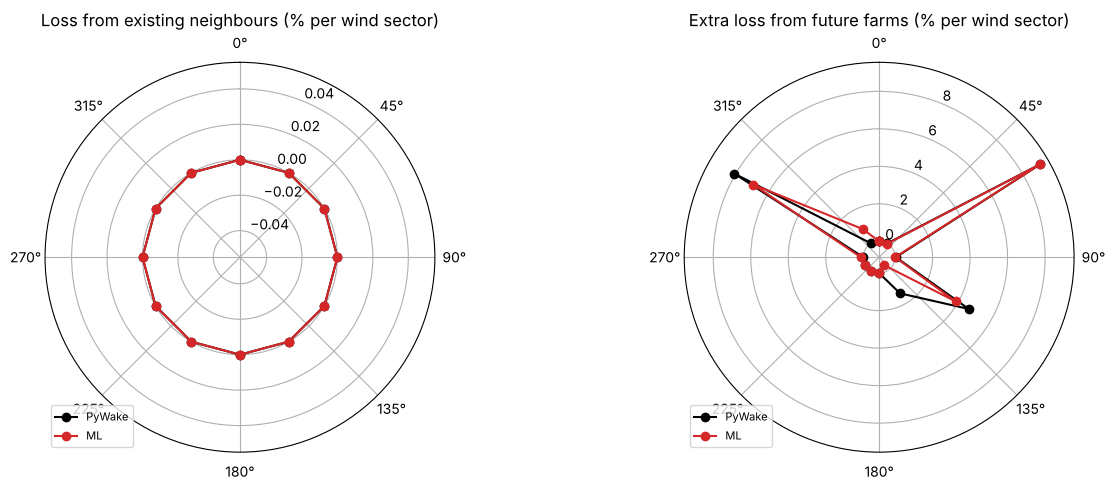

In [16]:
def sector_loss(res, a, b):
    pa = (farm_power(res[a]) * P).sum(axis=1); pb = (farm_power(res[b]) * P).sum(axis=1)
    return (1 - pb / pa) * 100

theta = np.radians(WD_BINS)
fig = plt.figure(figsize=(13, 5))
for k, (a, b, title) in enumerate([("alone", "existing", "Loss from existing neighbours"),
                                   ("existing", "existing+future", "Extra loss from future farms")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="polar")
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    for method, res, c in [("PyWake", pw, "k"), ("ML", ml, "tab:red")]:
        v = sector_loss(res, a, b)
        ax.plot(np.r_[theta, theta[0]], np.r_[v, v[0]], "o-", color=c, label=method)
    ax.set_title(title + " (% per wind sector)"); ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, f"{FIG_PREFIX}_sector_loss.png"), dpi=150, bbox_inches="tight"); plt.show()

## 8. Layout uncertainty of the future build-out

The future turbine positions are unknown, so the future layout is resampled `N_MC_FUTURE` times (real polygons, random spacing-constrained
positions). Existing farms keep their real positions. Both methods are run on every sample so the ML uncertainty can be checked against PyWake.

In [17]:
mc_rows = []
a_pw, a_ml = weighted(pw["alone"], in_range), weighted(ml["alone"], in_range)
e_pw, e_ml = weighted(pw["existing"], in_range), weighted(ml["existing"], in_range)
for s in range(N_MC_FUTURE):
    lay = pd.concat([layout_existing, future_layout(RANDOM_SEED + 1000 + s)], ignore_index=True)
    f_pw, f_ml = weighted(pywake_target_power(lay), in_range), weighted(ml_target_power(lay), in_range)
    mc_rows.append(dict(sample=s, PyWake_extra_loss_pct=(1 - f_pw / e_pw) * 100, ML_extra_loss_pct=(1 - f_ml / e_ml) * 100,
                        PyWake_total_loss_pct=(1 - f_pw / a_pw) * 100, ML_total_loss_pct=(1 - f_ml / a_ml) * 100))
mc = pd.DataFrame(mc_rows)
print(mc.drop(columns="sample").agg(["mean", "std", "min", "max"]).round(3))
mc.round(3)

      PyWake_extra_loss_pct  ML_extra_loss_pct  PyWake_total_loss_pct  \
mean                  1.687              1.358                  1.687   
std                   0.035              0.061                  0.035   
min                   1.633              1.260                  1.633   
max                   1.742              1.473                  1.742   

      ML_total_loss_pct  
mean              1.358  
std               0.061  
min               1.260  
max               1.473  


,sample,PyWake_extra_loss_pct,ML_extra_loss_pct,PyWake_total_loss_pct,ML_total_loss_pct
0,0,1.689,1.363,1.689,1.363
1,1,1.666,1.323,1.666,1.323
2,2,1.704,1.391,1.704,1.391
3,3,1.677,1.323,1.677,1.323
4,4,1.646,1.260,1.646,1.260
5,5,1.742,1.473,1.742,1.473
6,6,1.710,1.315,1.710,1.315
7,7,1.633,1.340,1.633,1.340
8,8,1.726,1.432,1.726,1.432
9,9,1.674,1.362,1.674,1.362


## 9. Summary

In [18]:
summary = losses[losses.ws_range == "4-15 m/s"].set_index("method")[["loss_existing_pct", "loss_total_pct", "extra_loss_from_future_pct"]]
summary["future_layout_std_pct"] = [mc.PyWake_extra_loss_pct.std(), mc.ML_extra_loss_pct.std()]
print("Wind-rose weighted inter-farm wake loss for", TARGET_FARM, "(ws 4-15 m/s, TI", TI, ")")
print(summary.round(2))
print()
print(benchmark[benchmark.ws_range.str.startswith("4-15")].set_index("scenario").round(4))

Wind-rose weighted inter-farm wake loss for Anholt (ws 4-15 m/s, TI 0.06 )
        loss_existing_pct  loss_total_pct  extra_loss_from_future_pct  \
method                                                                  
PyWake                0.0            1.70                        1.70   
ML                    0.0            1.39                        1.39   

        future_layout_std_pct  
method                         
PyWake                   0.03  
ML                       0.06  

                                  ws_range  turbine_R2  turbine_MAE  \
scenario                                                              
alone            4-15 m/s (training range)      0.9939       0.0092   
existing         4-15 m/s (training range)      0.9939       0.0092   
existing+future  4-15 m/s (training range)      0.9918       0.0132   

                 farm_power_MAPE_pct  farm_power_bias_pct  
scenario                                                   
alone                      